# Quick overview

## Create the simulation

In [ ]:
import numpy as np
from lucifex.fdm import AB, CN
from lucifex.io import write
from lucifex.sim import run, xdmf_to_npz
from lucifex.viz import (
    plot_colormap, plot_contours, get_ipynb_file_name, set_ipynb_variable,
)
from lucifex.utils.array_utils import as_indices
from crocodil.dns.theory import threshold_rayleigh
from crocodil.dns.system_c import dns_system_c, plot_gravity_arrow, SYSTEM_C_REFERENCE

STORE = 1
WRITE = None
DIR_ROOT = f'./{get_ipynb_file_name()}'
NX = set_ipynb_variable('NX', 100)
NY = set_ipynb_variable('NY', 100)
ANIM = set_ipynb_variable('ANIM', False)

simulation = dns_system_c(
    store_delta=STORE, 
    write_delta=WRITE, 
    dir_root=DIR_ROOT, 
    dir_datetime=True,
    dir_uid=True,
)(
    Nx=NX,
    Ny=NY,
    cell='quadrilateral',
    scaling='advective',
    **SYSTEM_C_REFERENCE.replace(Ra=800.0),
    D_adv=AB(1)@CN, 
    D_diff=AB(1)@CN,
    dt_max=0.1,
    courant_adv=0.75,
    courant_diff=0.75,
    courant_reac=0.1,
    c_stabilization=None,
    c_limits=(0,1),
    diagnostic=True,
)

Lx, Ly = simulation['Lx', 'Ly']
Ra, Da, epsilon, beta, zeta_min, sr, cr = (
    float(i) for i in simulation['Ra', 'Da', 'epsilon', 'beta', 'zeta_min', 'sr', 'cr']
)

Ra_thresh = threshold_rayleigh(Lx, Ly, NX, 2)
print(f"Ra = {Ra} , Ra_thresh = {Ra_thresh}")

Ra = 800.0 , Ra_thresh = 2250.0


## Run the simulation

In [2]:
n_stop = set_ipynb_variable('N_STOP', 600)
t_stop = 100.0
dt_init = 1e-6
n_init = 10

write(simulation.parameters, simulation.parameter_file, simulation.dir_path, mode='w')
run(simulation, n_stop=n_stop, t_stop=t_stop, dt_init=dt_init, n_init=n_init, show_progress=True)
if WRITE:
    xdmf_to_npz(simulation, delete_xdmf=False)

s, c, psi, u = simulation['s', 'c', 'psi', 'u']
mC, mD = simulation['mC', 'mD']

100%|██████████| 600/600 [04:21<00:00,  2.29it/s]


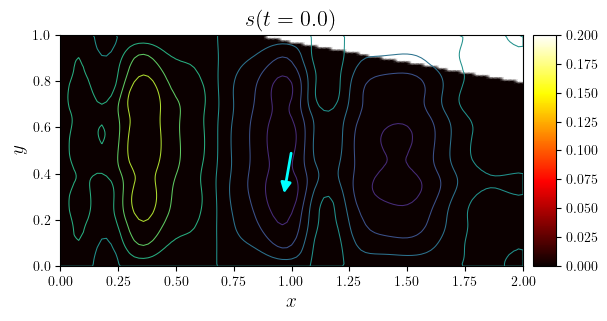

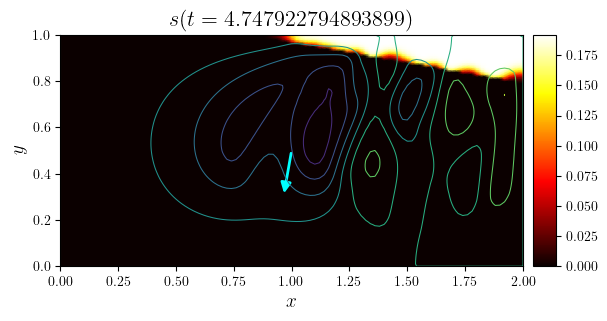

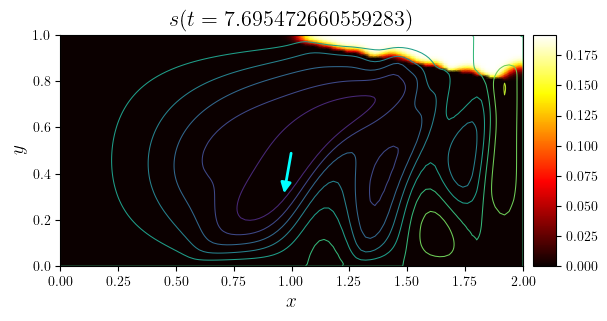

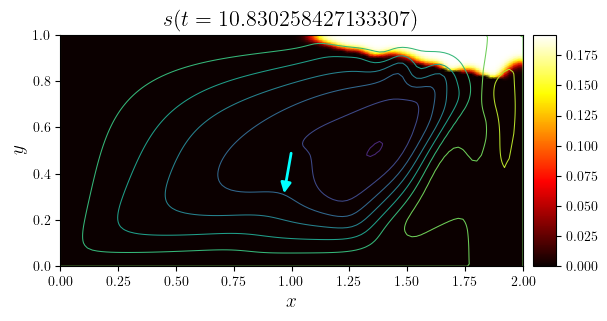

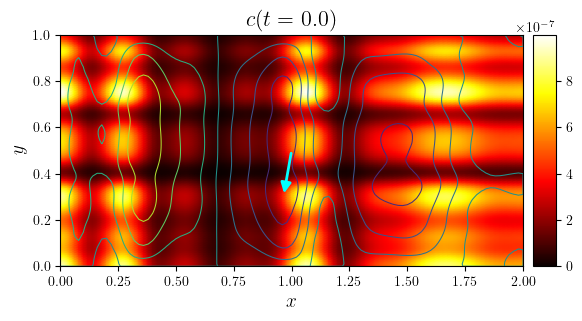

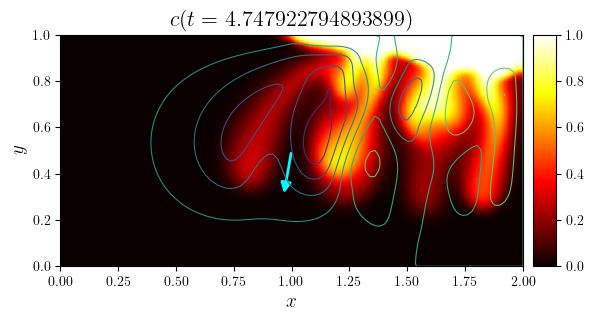

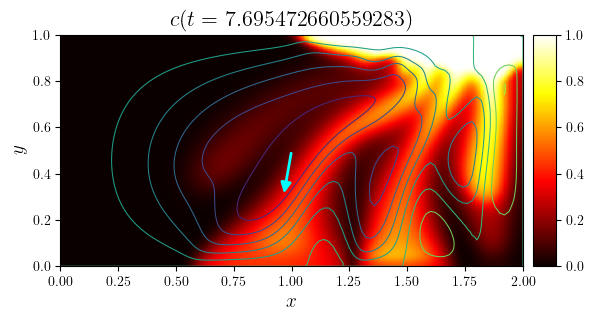

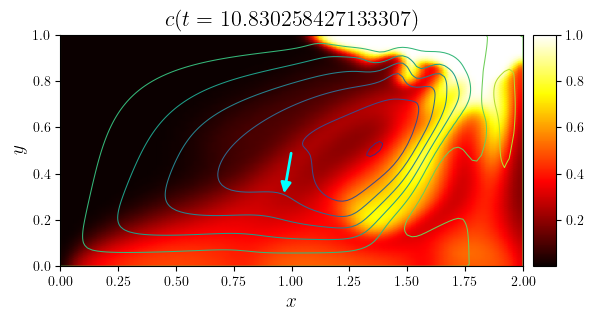

In [11]:
time_indices = as_indices(c.time_series, (0, 0.5, 0.75, -1), fraction=True)

for q in (s, c):
    for i in time_indices:
        fig, ax = plot_colormap(q.series[i], title=f'${q.name}(t={q.time_series[i]})$')
        plot_gravity_arrow(ax, 0.5 * np.array((Lx, Ly)), 0.2, beta)
        plot_contours(fig, ax, psi.series[i], cmap='viridis')